Data loaded successfully.


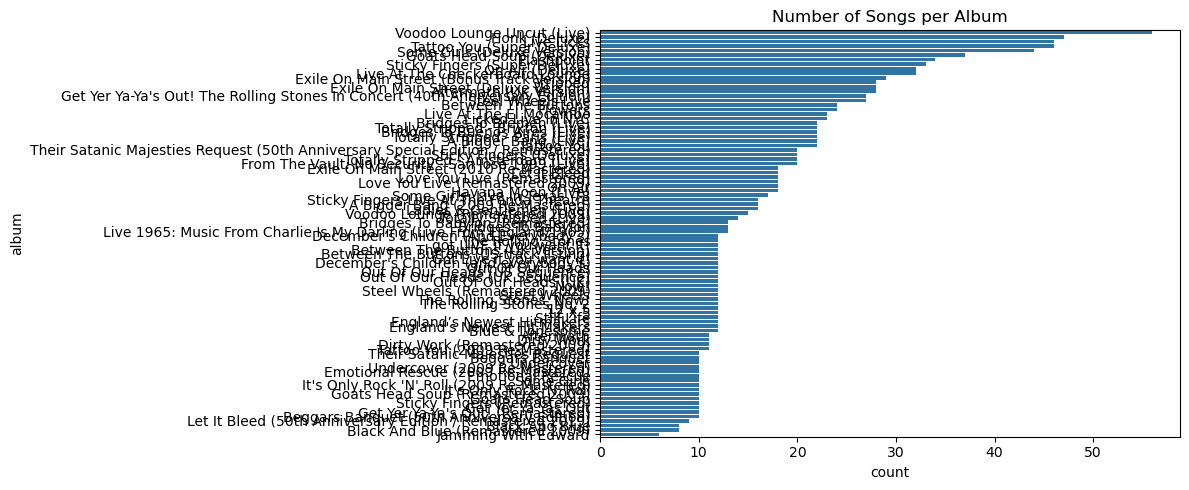

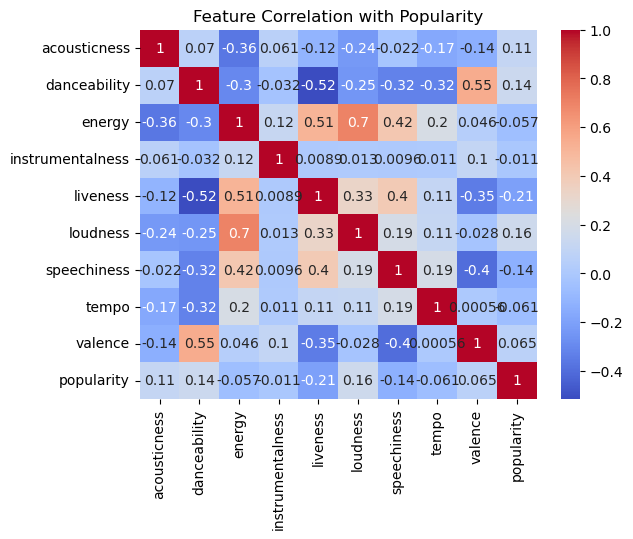

Top Recommended Albums:
 album
Tattoo You (2009 Re-Mastered)    1
Some Girls                       1
Name: count, dtype: int64
Explained Variance Ratio: [0.32446344 0.17938047]


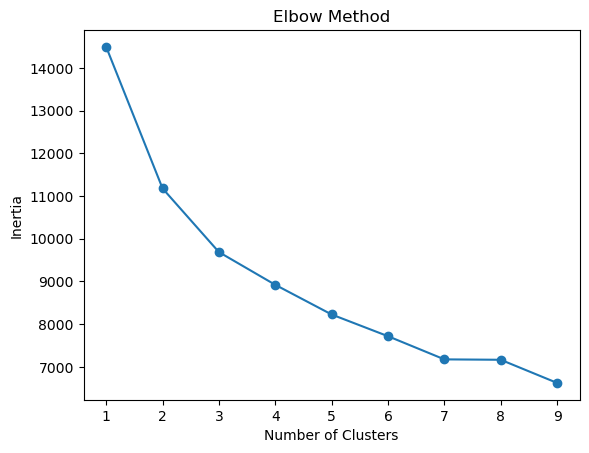

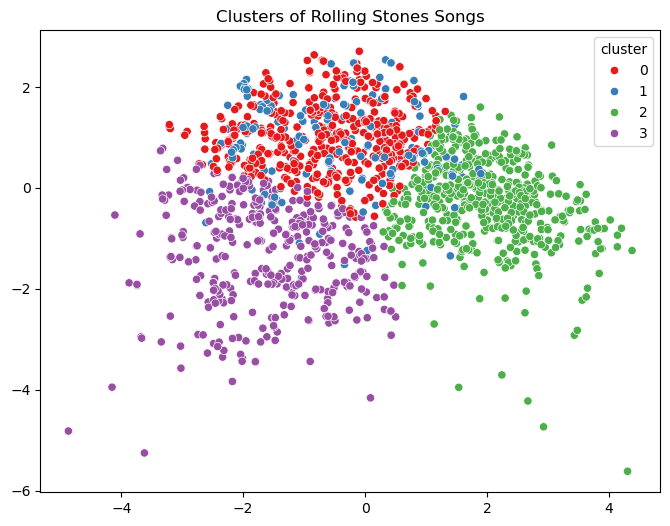

Cluster Summary:
          acousticness  danceability    energy  instrumentalness  liveness  \
cluster                                                                     
0            0.162356      0.546517  0.827142          0.054973  0.326251   
1            0.254519      0.516104  0.820124          0.741067  0.402861   
2            0.192855      0.351109  0.928831          0.129756  0.843017   
3            0.432027      0.499953  0.561159          0.067292  0.291468   

         loudness  speechiness       tempo   valence  popularity  
cluster                                                           
0       -6.425866     0.051092  123.288579  0.757535   22.970060  
1       -6.901570     0.049943  122.990668  0.740467   21.404145  
2       -5.280640     0.112451  138.823669  0.427917   17.636187  
3       -9.847485     0.046964  114.756045  0.484831   21.803483  


In [5]:
# 🎵 Rolling Stones Spotify Clustering Project

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Step 2: Load the Dataset
df = pd.read_csv("rolling_stones_spotify.csv")
print("Data loaded successfully.")
df.head()

# Step 3: Clean the Data
df.drop(['Unnamed: 0', 'id', 'uri'], axis=1, inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'])
df.dropna(inplace=True)

# Step 4: Songs per Album (EDA)
plt.figure(figsize=(12,5))
sns.countplot(data=df, y='album', order=df['album'].value_counts().index)
plt.title("Number of Songs per Album")
plt.tight_layout()
plt.show()

# Step 5: Correlation Heatmap
features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'popularity']

sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Popularity")
plt.show()

# Step 6: Top 2 Albums with Most Popular Songs
popular_df = df[df['popularity'] >= 70]
top_albums = popular_df['album'].value_counts().head(2)
print("Top Recommended Albums:\n", top_albums)

# Step 7: Feature Scaling
X = df[features].drop(columns=['popularity'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Dimensionality Reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Step 9: Elbow Method to Find Optimal Clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Step 10: Apply KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Step 11: Visualize the Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='Set1')
plt.title("Clusters of Rolling Stones Songs")
plt.show()

# Step 12: Cluster Summary
cluster_summary = df.groupby('cluster')[features].mean()
print("Cluster Summary:\n", cluster_summary)
